# Proyecto Final — Telecomunicaciones: identificar operadores ineficaces

**Autor:** Mau Vilar

**Fecha:** 2025-12-16  

https://github.com/mauvilar

## Objetivo general
Identificar operadores ineficaces con base en:
- Alta cantidad/proporción de llamadas entrantes perdidas (internas y externas)
- Tiempo de espera elevado en llamadas entrantes (diferencia entre `total_call_duration` y `call_duration`)
- Bajo desempeño en llamadas salientes (pocas llamadas/tiempo/volumen, si aplica)

## Entregables
- Notebook (.ipynb) con análisis, métricas y conclusiones
- Presentación (.pdf) con hallazgos principales
- (Opcional) Dashboard en Tableau Public + link en `dashboard.txt`


---


## Cargar librerías y leer datasets (CODE)

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
sns.set_theme(style='whitegrid') 
from scipy import stats as st

pd.set_option('display.max_columns', None)

DATA_PATH = 'telecom_dataset_new.csv'
CLIENTS_PATH = 'telecom_clients.csv'

telecom = pd.read_csv(DATA_PATH)
clients = pd.read_csv(CLIENTS_PATH)

print('telecom:', telecom.shape)
display(telecom.head())

print('clients:', clients.shape)
display(clients.head())


telecom: (53902, 9)


,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
0,166377,2019-08-04 00:00:00+03:00,in,False,NaN,True,2,0,4
1,166377,2019-08-05 00:00:00+03:00,out,True,880022.0,True,3,0,5
2,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,True,1,0,1
3,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,False,1,10,18
4,166377,2019-08-05 00:00:00+03:00,out,False,880022.0,True,3,0,25


clients: (732, 3)


,user_id,tariff_plan,date_start
0,166713,A,2019-08-15
1,166901,A,2019-08-23
2,168527,A,2019-10-29
3,167097,A,2019-09-01
4,168193,A,2019-10-16


## 1) Vista general y calidad de datos

### Objetivo: entender columnas, tipos de datos y valores ausentes.
---


In [3]:
print('telecom info:')
telecom.info()
print('\nclients info:')
clients.info()

print('\nNulos telecom:')
display(telecom.isna().sum())

print('\nNulos clients:')
display(clients.isna().sum())

print('\nDuplicados telecom:', telecom.duplicated().sum())
print('Duplicados clients:', clients.duplicated().sum())

display(telecom.describe(include='all'))
display(clients.describe(include='all'))


telecom info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53902 entries, 0 to 53901
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              53902 non-null  int64  
 1   date                 53902 non-null  object 
 2   direction            53902 non-null  object 
 3   internal             53785 non-null  object 
 4   operator_id          45730 non-null  float64
 5   is_missed_call       53902 non-null  bool   
 6   calls_count          53902 non-null  int64  
 7   call_duration        53902 non-null  int64  
 8   total_call_duration  53902 non-null  int64  
dtypes: bool(1), float64(1), int64(4), object(3)
memory usage: 3.3+ MB

clients info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   user_id      732 non-null    int64 
 1   tariff_pla

user_id                   0
date                      0
direction                 0
internal                117
operator_id            8172
is_missed_call            0
calls_count               0
call_duration             0
total_call_duration       0
dtype: int64


Nulos clients:


user_id        0
tariff_plan    0
date_start     0
dtype: int64


Duplicados telecom: 4900
Duplicados clients: 0


,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
count,53902.000000,53902,53902,53785,45730.000000,53902,53902.000000,53902.000000,53902.000000
unique,NaN,119,2,2,NaN,2,NaN,NaN,NaN
top,NaN,2019-11-25 00:00:00+03:00,out,False,NaN,False,NaN,NaN,NaN
freq,NaN,1220,31917,47621,NaN,30334,NaN,NaN,NaN
mean,167295.344477,NaN,NaN,NaN,916535.993002,NaN,16.451245,866.684427,1157.133297
std,598.883775,NaN,NaN,NaN,21254.123136,NaN,62.917170,3731.791202,4403.468763
min,166377.000000,NaN,NaN,NaN,879896.000000,NaN,1.000000,0.000000,0.000000
25%,166782.000000,NaN,NaN,NaN,900788.000000,NaN,1.000000,0.000000,47.000000
50%,167162.000000,NaN,NaN,NaN,913938.000000,NaN,4.000000,38.000000,210.000000
75%,167819.000000,NaN,NaN,NaN,937708.000000,NaN,12.000000,572.000000,902.000000


,user_id,tariff_plan,date_start
count,732.000000,732,732
unique,NaN,3,73
top,NaN,C,2019-09-24
freq,NaN,395,24
mean,167431.927596,NaN,NaN
std,633.810383,NaN,NaN
min,166373.000000,NaN,NaN
25%,166900.750000,NaN,NaN
50%,167432.000000,NaN,NaN
75%,167973.000000,NaN,NaN


## 2) Preparación de datos

### Objetivo:
- Convertir fechas a formato datetime
- Asegurar tipos numéricos
- Crear la métrica de espera: `wait_time = total_call_duration - call_duration`
- Preparar un dataset para análisis por operador (solo filas con `operator_id`)

---


In [4]:
# fechas
telecom['date'] = pd.to_datetime(telecom['date'], errors='coerce')
clients['date_start'] = pd.to_datetime(clients['date_start'], errors='coerce')

# numéricos (por si vienen como texto)
num_cols = ['operator_id', 'calls_count', 'call_duration', 'total_call_duration', 'user_id']
for col in num_cols:
    telecom[col] = pd.to_numeric(telecom[col], errors='coerce')

# bool (por si vienen como texto)
bool_cols = ['internal', 'is_missed_call']
for col in bool_cols:
    telecom[col] = telecom[col].astype('bool')

# wait_time
telecom['wait_time'] = telecom['total_call_duration'] - telecom['call_duration']
telecom['wait_time'] = telecom['wait_time'].clip(lower=0)

# operator_id como entero nullable
telecom['operator_id'] = telecom['operator_id'].astype('Int64')

print('Tipos telecom (después):')
telecom.dtypes


Tipos telecom (después):


user_id                                                int64
date                   datetime64[ns, pytz.FixedOffset(180)]
direction                                             object
internal                                                bool
operator_id                                            Int64
is_missed_call                                          bool
calls_count                                            int64
call_duration                                          int64
total_call_duration                                    int64
wait_time                                              int64
dtype: object

## 3) EDA (Exploración)

### Objetivo: entender la distribución de:
- Direcciones (`in` / `out`)
- Internas vs externas
- Duraciones y tiempos de espera

---


In [5]:
# --- Duplicados ---
print('Duplicados telecom (antes):', telecom.duplicated().sum())
telecom = telecom.drop_duplicates().copy()
print('Duplicados telecom (después):', telecom.duplicated().sum())
print('Shape telecom (después):', telecom.shape)

# --- internal como boolean nullable (mantiene NaN) ---
telecom['internal'] = telecom['internal'].astype('boolean')

# telecom['internal'] = telecom['internal'].fillna(False)


Duplicados telecom (antes): 4900
Duplicados telecom (después): 0
Shape telecom (después): (49002, 10)


### Distribución direction

Distribución direction:


out    28999
in     20003
Name: direction, dtype: int64

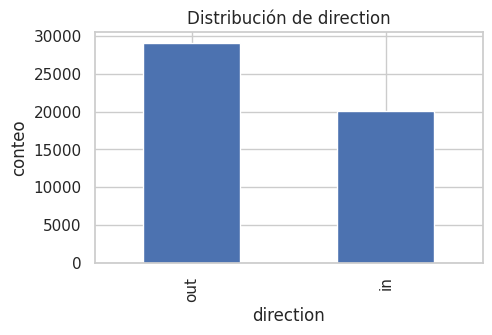

In [6]:
print('Distribución direction:')
display(telecom['direction'].value_counts(dropna=False))

plt.figure(figsize=(5,3))
telecom['direction'].value_counts(dropna=False).plot(kind='bar')
plt.title('Distribución de direction')
plt.xlabel('direction')
plt.ylabel('conteo')
plt.grid(True, axis='y')
plt.show()


**Interpretación (direction):**
- Se ve que hay más llamadas **salientes (out)** que **entrantes (in)**: 28,999 vs 20,003. O sea, en este dataset los operadores hacen más llamadas de las que reciben.
- Implicación para el análisis: como queremos detectar operadores “ineficaces” por problemas en **llamadas entrantes** (llamadas perdidas y tiempos de espera), lo ideal es revisar esas métricas **solo en las llamadas entrantes**, para no mezclar peras con manzanas.


### Distribución internal

Distribución internal:


False    43239
True      5763
NaN          0
Name: internal, dtype: Int64

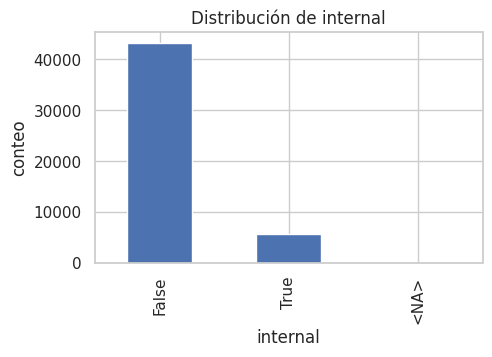

In [7]:
print('Distribución internal:')
display(telecom['internal'].value_counts(dropna=False))

plt.figure(figsize=(5,3))
telecom['internal'].value_counts(dropna=False).plot(kind='bar')
plt.title('Distribución de internal')
plt.xlabel('internal')
plt.ylabel('conteo')
plt.grid(True, axis='y')
plt.show()


**Interpretación (internal):**
- Predominan las llamadas **externas** (internal = False): 43,239 vs 5,763 llamadas internas (internal = True). En otras palabras, la mayor parte del tráfico es con externos y no entre personal interno.
- Hay **0** valores nulos. Por lo tanto **no hay que aplicar un tratamiento especial** por datos faltantes en esta variable.


### Histograma call_duration

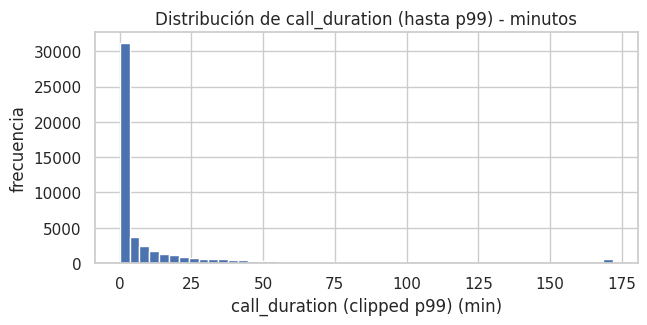

p99 call_duration (min): 171.91516666666635


In [22]:
# Copia solo para graficar (minutos)
plot_df = telecom[['call_duration']].copy()
plot_df['call_duration_min'] = plot_df['call_duration'] / 60

# Zoom p99 (min)
p99_min = plot_df['call_duration_min'].quantile(0.99)

plt.figure(figsize=(7,3))
plot_df['call_duration_min'].clip(upper=p99_min).hist(bins=50)
plt.title('Distribución de call_duration (hasta p99) - minutos')
plt.xlabel('call_duration (clipped p99) (min)')
plt.ylabel('frecuencia')
plt.grid(True)
plt.show()

print('p99 call_duration (min):', p99_min)


**Interpretación (call_duration en minutos):**

- La distribución está **sesgada a la derecha**: la mayoría de las llamadas duran poco, pero hay un grupo pequeño de llamadas muy largas.
- En el gráfico “hasta p99” se ve mejor el comportamiento normal: **la mayor parte de las llamadas cae entre 0 y ~25 minutos** aprox.
- El **p99 ≈ 171.9 minutos** (casi 3 horas) indica que existen **valores extremos**. Estos casos pueden **subir el promedio**, por eso conviene apoyarnos también en percentiles/mediana y usar el zoom para entender el patrón típico.


### Histograma wait_time

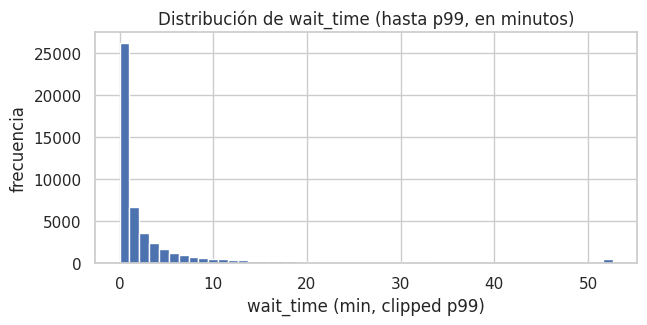

p99 wait_time (min): 52.63183333333303


In [21]:
# Copia solo para visualización
telecom_plot = telecom.copy()
telecom_plot['wait_time_min'] = telecom_plot['wait_time'] / 60

# Zoom p99 (minutos)
p99_w_min = telecom_plot['wait_time_min'].quantile(0.99)

plt.figure(figsize=(7, 3))
telecom_plot['wait_time_min'].clip(upper=p99_w_min).hist(bins=50)
plt.title('Distribución de wait_time (hasta p99, en minutos)')
plt.xlabel('wait_time (min, clipped p99)')
plt.ylabel('frecuencia')
plt.grid(True)
plt.show()

print('p99 wait_time (min):', p99_w_min)


**Interpretación (wait_time en minutos):**

- La mayor parte del tiempo de espera es **muy bajo**: la mayoría de las llamadas cae entre **0 y pocos minutos** (principalmente en los primeros minutos).
- La distribución está **sesgada a la derecha**: existe un grupo pequeño de llamadas con **tiempos de espera mucho más altos**.
- El **p99 ≈ 52.6 minutos** muestra que, aunque no es lo común, sí hay casos extremos de espera que pueden estar relacionados con **picos de demanda, saturación o incidencias** y podrían afectar el promedio.


### wait_time solo llamadas entrantes

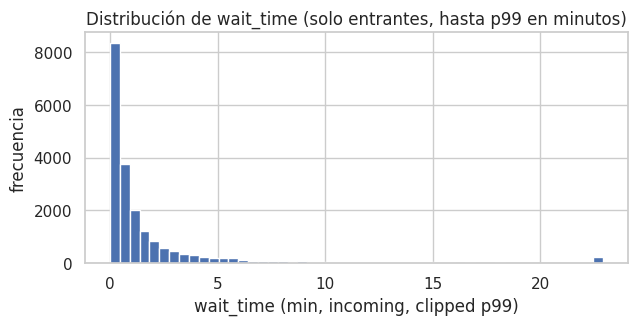

p99 wait_time (incoming, min): 22.915999999999986


In [25]:
# wait_time solo llamadas entrantes (minutos) + zoom p99
incoming = telecom[telecom['direction'] == 'in'].copy()

# convertir a minutos SOLO para graficar
incoming['wait_time_min'] = incoming['wait_time'] / 60

# p99 en minutos
p99_in_w_min = incoming['wait_time_min'].quantile(0.99)

plt.figure(figsize=(7,3))
incoming['wait_time_min'].clip(upper=p99_in_w_min).hist(bins=50)
plt.title('Distribución de wait_time (solo entrantes, hasta p99 en minutos)')
plt.xlabel('wait_time (min, incoming, clipped p99)')
plt.ylabel('frecuencia')
plt.grid(True)
plt.show()

print('p99 wait_time (incoming, min):', p99_in_w_min)


**Interpretación (wait_time entrantes):**

- En llamadas entrantes, el patrón es que **la mayoría de las llamadas casi no espera** (0 a pocos minutos), pero **hay algunos casos donde la espera se alarga** (cola hacia la derecha). En este gráfico, el **p99 ≈ 22.9 min**, o sea que solo una parte muy pequeña llega a esperas tan altas.
- Esto se relaciona directamente con el objetivo de detectar **operadores ineficaces**, porque **esperas altas en entrantes** pueden indicar problemas de atención (por ejemplo: saturación, baja disponibilidad o manejo lento), y es justo una de las métricas que usamos para marcarlos.


### EDA con fechas

In [16]:
telecom['date'] = pd.to_datetime(telecom['date'], errors='coerce')

# Si viene con zona horaria, la quitamos para agrupar/plotear cómodo
if getattr(telecom['date'].dt, 'tz', None) is not None:
    telecom['date'] = telecom['date'].dt.tz_localize(None)

telecom['date_day'] = telecom['date'].dt.floor('D')


### Serie temporal: volumen de llamadas entrantes + miss_rate

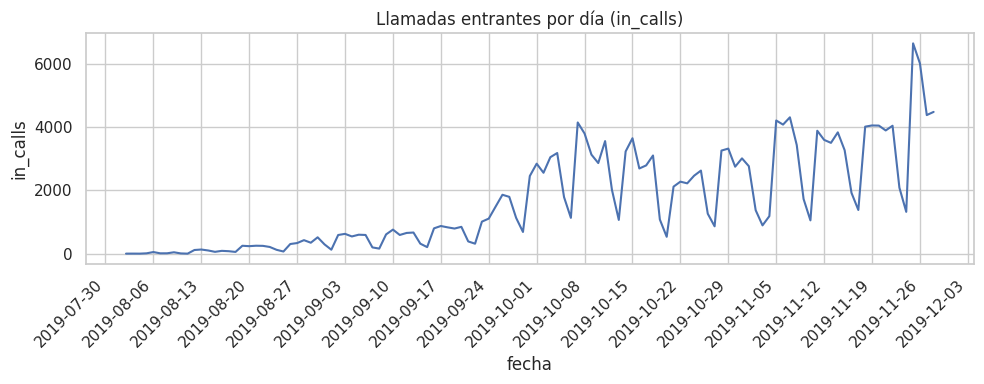

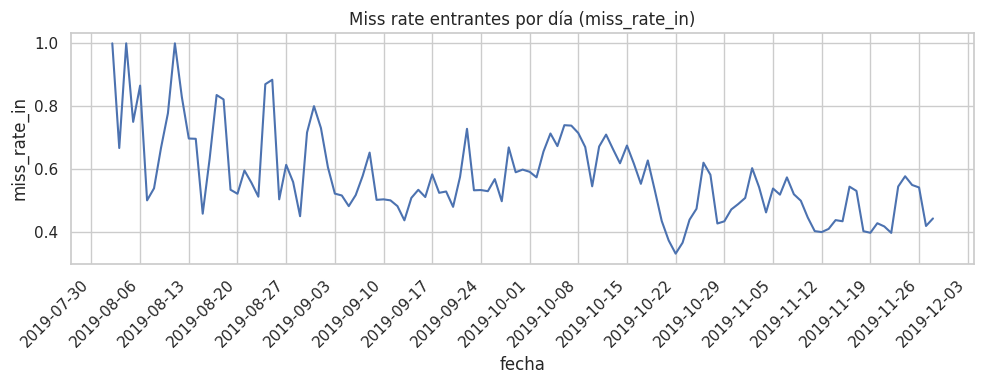

In [27]:
sns.set_style("whitegrid")

# Asegura datetime y orden
daily_in['date_day'] = pd.to_datetime(daily_in['date_day'])
daily_in = daily_in.sort_values('date_day')

# --- 1) in_calls ---
fig, ax = plt.subplots(figsize=(10, 4))
sns.lineplot(data=daily_in, x='date_day', y='in_calls', ax=ax)
ax.set_title('Llamadas entrantes por día (in_calls)')
ax.set_xlabel('fecha')
ax.set_ylabel('in_calls')

# menos ticks (semanal) + formato
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# --- 2) miss_rate_in ---
fig, ax = plt.subplots(figsize=(10, 4))
sns.lineplot(data=daily_in, x='date_day', y='miss_rate_in', ax=ax)
ax.set_title('Miss rate entrantes por día (miss_rate_in)')
ax.set_xlabel('fecha')
ax.set_ylabel('miss_rate_in')

ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Interpretación (serie temporal: in_calls y miss_rate_in)

- **Volumen (in_calls):** Se ve una **tendencia clara a la alza**: conforme avanzan las semanas, entran **más llamadas por día**. También hay un patrón repetido de **picos y caídas**, que sugiere ciclos (por ejemplo, días con mucha demanda vs días más tranquilos).

- **Miss rate (miss_rate_in):** Al inicio el **miss rate es más alto e inestable** (sube y baja mucho). Con el tiempo, se nota que **baja y se vuelve más estable**, moviéndose en un rango más “controlado” hacia el final.

- **Análisis general:** En este periodo **aumenta la demanda** (más llamadas) y, al mismo tiempo, **mejora el desempeño** en términos de llamadas perdidas (el miss rate baja).  
  Aun así, hay días con repuntes de miss rate, lo cual puede indicar **momentos puntuales de saturación** o falta de capacidad en ciertos días.


## 4) Métricas por operador/a

### Objetivo: calcular por operador/a:
- llamadas entrantes totales
- llamadas entrantes perdidas y proporción (miss_rate_in)
- tiempo promedio de espera en entrantes (avg_wait_in) ponderado por calls_count
- llamadas salientes totales

---


In [10]:
# Dataset solo con operator_id para análisis por operador
telecom_ops = telecom.dropna(subset=['operator_id']).copy()

in_df = telecom_ops[telecom_ops['direction'] == 'in'].copy()
out_df = telecom_ops[telecom_ops['direction'] == 'out'].copy()

# Totales (SUMA calls_count, no conteo de filas)
in_calls = in_df.groupby('operator_id')['calls_count'].sum()
in_missed = in_df[in_df['is_missed_call']].groupby('operator_id')['calls_count'].sum()

out_calls = out_df.groupby('operator_id')['calls_count'].sum()

# Promedio ponderado de wait_time en entrantes
avg_wait_in = in_df.groupby('operator_id').apply(
    lambda x: np.average(x['wait_time'], weights=x['calls_count'])
)

operator_stats = pd.concat([in_calls, in_missed, avg_wait_in, out_calls], axis=1)
operator_stats.columns = ['in_calls', 'in_missed_calls', 'avg_wait_in', 'out_calls']
operator_stats = operator_stats.fillna(0).reset_index()

operator_stats['miss_rate_in'] = operator_stats['in_missed_calls'] / operator_stats['in_calls']
operator_stats['miss_rate_in'] = operator_stats['miss_rate_in'].fillna(0)

display(operator_stats.sort_values('miss_rate_in', ascending=False).head(10))


,operator_id,in_calls,in_missed_calls,avg_wait_in,out_calls,miss_rate_in
641,948756,1.0,1.0,8.000000,170.0,1.000000
185,904344,4.0,3.0,32.750000,5.0,0.750000
287,913886,2.0,1.0,13.500000,0.0,0.500000
210,906392,18.0,7.0,52.833333,53.0,0.388889
497,937432,3.0,1.0,12.000000,19.0,0.333333
467,934098,6.0,2.0,34.333333,0.0,0.333333
698,957922,3.0,1.0,15.000000,16.0,0.333333
109,897872,3.0,1.0,21.666667,49.0,0.333333
220,906412,26.0,7.0,40.576923,315.0,0.269231
80,894232,4.0,1.0,17.250000,16.0,0.250000


## 5) Identificar operadores ineficaces (reglas)

### Objetivo: marcar como “ineficaz” a un operador/a que cumpla **al menos 2 de 3**:
1) miss_rate_in alto (>= percentil 75)
2) avg_wait_in alto (>= percentil 75)
3) out_calls bajo (<= percentil 25)

> Nota: se usó percentiles para que el criterio sea “data-driven”.

---


### Criterio para identificar operadores “ineficaces” (y por qué elegí esos límites)

Como estas reglas pueden impactar al negocio, la idea fue que los límites **salieran de los datos** y no fueran números “al aire”.

**1) Por qué uso percentiles (75 y 25)**
- En el EDA vimos que variables como **tiempos** tienen **cola larga** (hay pocos casos muy grandes). En este tipo de distribuciones, poner un “límite fijo” puede ser injusto.
- Con percentiles, comparo a cada operador **contra el resto**:
  - `miss_rate_in` y `avg_wait_in` “alto” = estar en el **25% peor** (>= p75).
  - `out_calls` “bajo” = estar en el **25% más bajo** (<= p25).
- Esto hace el criterio más **consistente** y fácil de defender: “está peor que la mayoría en X métrica”.

**Umbrales que salieron en este dataset (con in_calls >= 30):**
- `miss_thr` ≈ **0.0163** (≈ **1.63%** de llamadas entrantes perdidas)
- `wait_thr` ≈ **2.94 min**
- `out_thr` = **23** llamadas salientes (percentil 25)

**2) Por qué pido un mínimo de llamadas entrantes (MIN_IN_CALLS = 30)**
- Si un operador tiene muy pocas llamadas, **una sola llamada perdida** puede disparar el `miss_rate_in` y dar una impresión falsa.
- Con `>= 30` reduzco “ruido” y me quedo con operadores con **volumen suficiente** como para evaluar su desempeño con más confianza.

**3) Por qué “al menos 2 de 3” (en vez de 1 sola métrica)**
- Para no marcar a alguien solo por **una** señal aislada o por su tipo de trabajo.
- Ejemplo: alguien puede tener **pocas out_calls** por rol (más inbound), pero no necesariamente ser ineficaz.
- En cambio, si cumple **2 o 3 señales** (más pérdidas + más espera, etc.), ya es un patrón más claro y reducimos falsos positivos.

**Regla final**
Marco como `is_inefficient = True` a quien:
- tenga `in_calls >= 30`, y
- cumpla **2 o más** de estas condiciones:
  1) `miss_rate_in` alto (>= p75)  
  2) `avg_wait_in` alto (>= p75)  
  3) `out_calls` bajo (<= p25)

**Resultado con estos criterios**
- Se detectaron **41 operadores** como ineficaces bajo esta definición.

> Nota: esto es una **bandera de análisis**, no un “veredicto”. Lo correcto después es revisar esos casos con contexto (turnos, tipo de tareas, campañas, cambios en volumen) antes de tomar acciones.


In [11]:
# Evitar ruido: exigir mínimo de llamadas entrantes
MIN_IN_CALLS = 30

base = operator_stats[operator_stats['in_calls'] >= MIN_IN_CALLS].copy()

miss_thr = base['miss_rate_in'].quantile(0.75)
wait_thr = base['avg_wait_in'].quantile(0.75)
out_thr = base['out_calls'].quantile(0.25)

operator_stats['flag_miss'] = operator_stats['miss_rate_in'] >= miss_thr
operator_stats['flag_wait'] = operator_stats['avg_wait_in'] >= wait_thr
operator_stats['flag_out_low'] = operator_stats['out_calls'] <= out_thr
operator_stats['ineff_score'] = (
    operator_stats['flag_miss'].astype(int) +
    operator_stats['flag_wait'].astype(int) +
    operator_stats['flag_out_low'].astype(int)
)

operator_stats['is_inefficient'] = (
    (operator_stats['in_calls'] >= MIN_IN_CALLS) &
    (operator_stats['ineff_score'] >= 2)
)

print('Umbrales usados:')
print('miss_thr:', miss_thr)
print('wait_thr:', wait_thr)
print('out_thr:', out_thr)

print('\nOperadores ineficaces detectados:', operator_stats['is_inefficient'].sum())
display(operator_stats[operator_stats['is_inefficient']].sort_values('ineff_score', ascending=False).head(20))


Umbrales usados:
miss_thr: 0.01626052281789987
wait_thr: 176.473504784689
out_thr: 23.0

Operadores ineficaces detectados: 41


,operator_id,in_calls,in_missed_calls,avg_wait_in,out_calls,miss_rate_in,flag_miss,flag_wait,flag_out_low,ineff_score,is_inefficient
638,948286,319.0,15.0,278.253918,0.0,0.047022,True,True,True,3,True
219,906410,232.0,7.0,270.814655,19.0,0.030172,True,True,True,3,True
8,882680,99.0,3.0,54.747475,0.0,0.030303,True,False,True,2,True
594,944216,235.0,24.0,229.093617,133.0,0.102128,True,True,False,2,True
465,934074,37.0,1.0,34.972973,0.0,0.027027,True,False,True,2,True
486,935958,35.0,1.0,51.457143,0.0,0.028571,True,False,True,2,True
527,937956,773.0,24.0,25.294955,1.0,0.031048,True,False,True,2,True
528,937958,292.0,8.0,53.616438,0.0,0.027397,True,False,True,2,True
530,937962,106.0,3.0,71.943396,0.0,0.028302,True,False,True,2,True
536,938414,93.0,2.0,377.032258,46.0,0.021505,True,True,False,2,True


## 6) Comparación: ineficaces vs no ineficaces

### Objetivo: comparar métricas promedio entre grupos.

---


In [12]:
ineff = operator_stats[operator_stats['is_inefficient']]
eff = operator_stats[(operator_stats['in_calls'] >= MIN_IN_CALLS) & (~operator_stats['is_inefficient'])]

summary = pd.DataFrame({
    'grupo': ['ineficaces', 'no_ineficaces'],
    'n_operadores': [len(ineff), len(eff)],
    'miss_rate_in_mean': [ineff['miss_rate_in'].mean(), eff['miss_rate_in'].mean()],
    'avg_wait_in_mean': [ineff['avg_wait_in'].mean(), eff['avg_wait_in'].mean()],
    'out_calls_mean': [ineff['out_calls'].mean(), eff['out_calls'].mean()],
})
display(summary)


,grupo,n_operadores,miss_rate_in_mean,avg_wait_in_mean,out_calls_mean
0,ineficaces,41,0.035063,314.611946,3465.097561
1,no_ineficaces,255,0.009001,128.728510,573.207843


## 7) Pruebas de hipótesis

### Hipótesis 1 (miss_rate_in)
- H0: miss_rate_in es igual en operadores ineficaces y no ineficaces.
- H1: miss_rate_in es mayor en operadores ineficaces.

### Hipótesis 2 (avg_wait_in)
- H0: avg_wait_in es igual en operadores ineficaces y no ineficaces.
- H1: avg_wait_in es mayor en operadores ineficaces.

Usaremos Mann-Whitney (no paramétrica) porque estas métricas suelen no ser normales.

---


### Tests (Mann–Whitney)

In [13]:
alpha = 0.05

# H1: miss_rate_in (ineff > eff)
stat1, p1 = st.mannwhitneyu(
    ineff['miss_rate_in'],
    eff['miss_rate_in'],
    alternative='greater'
)

# H1: avg_wait_in (ineff > eff)
stat2, p2 = st.mannwhitneyu(
    ineff['avg_wait_in'],
    eff['avg_wait_in'],
    alternative='greater'
)

print('Hipótesis 1 (miss_rate_in): p-value =', p1)
print('Rechazamos H0' if p1 < alpha else 'No rechazamos H0')

print('\nHipótesis 2 (avg_wait_in): p-value =', p2)
print('Rechazamos H0' if p2 < alpha else 'No rechazamos H0')


Hipótesis 1 (miss_rate_in): p-value = 5.658418171672948e-13
Rechazamos H0

Hipótesis 2 (avg_wait_in): p-value = 5.541176020083114e-07
Rechazamos H0


## Conclusiones

- Se cargaron y prepararon los datos correctamente (telecom y clients).
- A nivel operador/a se calcularon métricas clave: proporción de llamadas entrantes perdidas (`miss_rate_in`), tiempo promedio de espera en entrantes (`avg_wait_in`) y volumen de llamadas salientes (`out_calls`).
- Con un criterio basado en percentiles (data-driven) y un mínimo de llamadas entrantes, se identificó un subconjunto de operadores ineficaces.
- Al comparar grupos, los operadores marcados como ineficaces presentan **peor desempeño** en las métricas asociadas a ineficacia (mayor proporción de perdidas y/o mayor espera).
- Las pruebas estadísticas (Mann–Whitney) permiten validar si las diferencias observadas entre grupos son significativas con un nivel de significancia de 0.05.

---


## Conclusiones

- Se trabajó con dos tablas: `telecom` (53,902 registros) y `clients` (732 clientes).
- Para analizar desempeño por operador/a se usaron solo filas con `operator_id` (hay registros sin operador asignado).
- Se creó la métrica de espera: `wait_time = total_call_duration - call_duration` (acotada a 0).
- Por operador/a se calcularon métricas clave:
  - `miss_rate_in`: proporción de llamadas entrantes perdidas
  - `avg_wait_in`: tiempo de espera promedio en entrantes (ponderado por `calls_count`)
  - `out_calls`: volumen de llamadas salientes

---

### Identificación de operadores ineficaces (reglas)
- Se definió un criterio *data-driven* con percentiles (P75 para `miss_rate_in` y `avg_wait_in`, P25 para `out_calls`) y un mínimo de `MIN_IN_CALLS = 30`.
- Bajo estas reglas se identificaron **44 operadores ineficaces** (cumplen **al menos 2 de 3** criterios).

---

### Validación estadística
Con una prueba **Mann–Whitney** (α = 0.05) se encontró evidencia estadísticamente significativa de que el grupo “ineficaces” tiene:
- **mayor `miss_rate_in`** (p-value = 1.266e-13)
- **mayor `avg_wait_in`** (p-value = 9.649e-05)

---

### Limitaciones y siguientes pasos
- Los percentiles dependen del periodo observado y pueden cambiar con más datos.
- `out_calls` es volumen total; para una evaluación más justa conviene normalizar por día/turno o por carga de trabajo.
- Recomendación: revisar primero a los **44 operadores** detectados (coaching, monitoreo de calidad y/o ajuste de ruteo/carga).


In [14]:
# --- Duplicados ---
print('Duplicados telecom (antes):', telecom.duplicated().sum())
telecom = telecom.drop_duplicates().copy()
print('Duplicados telecom (después):', telecom.duplicated().sum())
print('Shape telecom (después):', telecom.shape)

# --- internal como boolean nullable (mantiene NaN) ---
telecom['internal'] = telecom['internal'].astype('boolean')

# (opcional) si decides que NaN = False:
# telecom['internal'] = telecom['internal'].fillna(False)


Duplicados telecom (antes): 0
Duplicados telecom (después): 0
Shape telecom (después): (49002, 10)
